<a href="https://colab.research.google.com/github/sagasameh/Weather-Condition-Classification-System/blob/main/Weather_Condition_Classification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Import necessary libraries for data manipulation, visualization, and machine learning models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
## Load Weather AUS dataset from Google Drive into a pandas DataFrame for analysis
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/weatherAUS.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [17]:
#Basic cleaning
# drop rows where target is missing
df = df.dropna(subset=["RainTomorrow"])

# remove duplicates
df = df.drop_duplicates()

In [18]:
#Split x and y
X = df.drop("RainTomorrow", axis=1)
Y = df["RainTomorrow"]

In [19]:
#Handling missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [20]:
#Encode categorical features
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le

In [21]:
#Encode target
target_le = LabelEncoder()
Y = target_le.fit_transform(Y)

In [22]:
#Train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [23]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
#Rndomforest model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

In [26]:
#Prediction
y_pred = model.predict(X_test)

In [27]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(Y_test, y_pred))

print(classification_report(Y_test, y_pred))

Accuracy: 0.8542494461830584
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22098
           1       0.76      0.51      0.61      6341

    accuracy                           0.85     28439
   macro avg       0.81      0.73      0.76     28439
weighted avg       0.85      0.85      0.84     28439



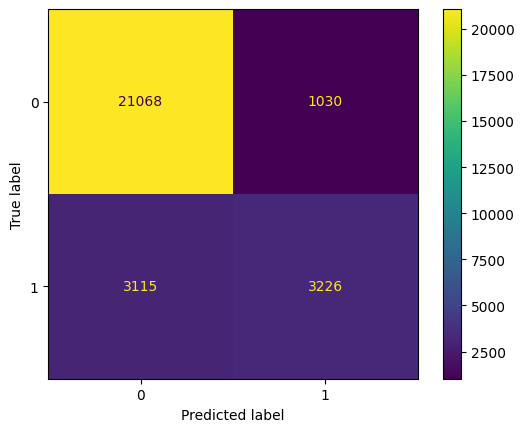

In [28]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()